In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim

# ── 1. Load MNIST ──
transform = transforms.ToTensor()
dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)  # bigger batch
print("Dataset ready! Images:", len(dataset))

# ── 2. Improved VAE ──
# CHANGE 1: Latent dim increased from 32 → 64
# CHANGE 2: Deeper encoder/decoder for better reconstruction
LATENT_DIM = 64  # was 32 — more information = better reconstruction

class ImprovedVAE(nn.Module):
    def __init__(self):
        super(ImprovedVAE, self).__init__()

        # Deeper encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.mean_layer = nn.Linear(128, LATENT_DIM)
        self.var_layer  = nn.Linear(128, LATENT_DIM)

        # Deeper decoder (mirrors encoder)
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        return self.mean_layer(x), self.var_layer(x)

    def reparameterise(self, mean, var):
        epsilon = torch.randn_like(var)
        return mean + var * epsilon

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mean, var = self.encode(x)
        z = self.reparameterise(mean, var)
        reconstructed = self.decode(z)
        return reconstructed, mean, var

model = ImprovedVAE()
print("Improved model ready!")
print(f"Latent dimension: {LATENT_DIM} floats = {LATENT_DIM * 4} bytes")

# ── 3. Improved Loss Function ──
# CHANGE 3: BCE loss instead of MSE — produces sharper MNIST digits
# CHANGE 4: Beta weighting on KL loss — better balance
BETA = 0.5  # weight on KL loss (lower = sharper reconstructions)

def loss_function(reconstructed, original, mean, var):
    original_flat = original.view(original.size(0), -1)

    # BCE loss (better than MSE for binary-ish images like MNIST)
    reconstruction_loss = nn.functional.binary_cross_entropy(
        reconstructed, original_flat, reduction='sum'
    )

    # KL divergence with beta weighting
    kl_loss = -0.5 * torch.sum(1 + var - mean.pow(2) - var.exp())

    return reconstruction_loss + BETA * kl_loss

# ── 4. Train for more epochs ──
# CHANGE 5: 50 epochs instead of 10
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
losses = []
print("Training started... (50 epochs, ~5-8 mins in Colab)")

for epoch in range(50):  # was 10
    total_loss = 0
    for images, _ in dataloader:
        optimizer.zero_grad()
        reconstructed, mean, var = model(images)
        loss = loss_function(reconstructed, images, mean, var)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    avg = total_loss / len(dataloader)
    losses.append(avg)

    if (epoch + 1) % 5 == 0:  # print every 5 epochs
        print(f"Epoch {epoch+1}/50 | Loss: {avg:.0f}")

print("Training complete!")

# ── 5. Save model ──
torch.save(model.state_dict(), 'vae_model_improved.pth')
print("Model saved as vae_model_improved.pth")

from google.colab import files
files.download('vae_model_improved.pth')

Dataset ready! Images: 60000
Improved model ready!
Latent dimension: 64 floats = 256 bytes
Training started... (50 epochs, ~5-8 mins in Colab)
Epoch 5/50 | Loss: 12471
Epoch 10/50 | Loss: 10738
Epoch 15/50 | Loss: 9948
Epoch 20/50 | Loss: 9384
Epoch 25/50 | Loss: 8930
Epoch 30/50 | Loss: 8731
Epoch 35/50 | Loss: 8573
Epoch 40/50 | Loss: 8453
Epoch 45/50 | Loss: 8297
Epoch 50/50 | Loss: 8244
Training complete!
Model saved as vae_model_improved.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Test the Encoder

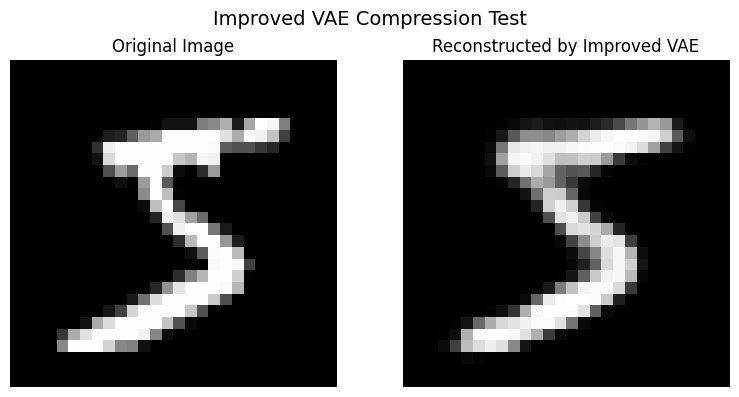

Original size:     784 numbers (784)
Compressed size:   64 numbers (64)
Compression ratio: 12x smaller!
Payload size:      256 bytes (64 floats x 4 bytes)


In [ ]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    test_image, label = dataset[0]
    test_input = test_image.unsqueeze(0)

    # ── ENCODE (compress) ──
    mean, var = model.encode(test_input)
    compressed = model.reparameterise(mean, var)

    # ── DECODE (rebuild) ──
    reconstructed = model.decode(compressed)
    reconstructed = reconstructed.view(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(test_image.squeeze(), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(reconstructed, cmap='gray')
axes[1].set_title("Reconstructed by Improved VAE")
axes[1].axis('off')

plt.suptitle("Improved VAE Compression Test", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Original size:     {test_image.numel()} numbers (784)")
print(f"Compressed size:   {compressed.numel()} numbers (64)")
print(f"Compression ratio: {test_image.numel() // compressed.numel()}x smaller!")
print(f"Payload size:      {compressed.numel() * 4} bytes (64 floats x 4 bytes)")

In [ ]:
# LoRa Packets Spliting

In [ ]:
import numpy as np

# ── Step 1: Get compressed latent vector ──
model.eval()
with torch.no_grad():
    test_image, _ = dataset[0]
    test_input = test_image.unsqueeze(0)
    mean, var = model.encode(test_input)
    compressed = model.reparameterise(mean, var)

# ── Step 2: Convert to bytes ──
compressed_bytes = compressed.numpy().astype(np.float32).tobytes()
print(f"Compressed data size: {len(compressed_bytes)} bytes")
print(f"(64 floats x 4 bytes each = 256 bytes total)")

# ── Step 3: Split into 6 LoRa packets ──
LORA_PACKET_SIZE = 48  # bytes per packet

packets = []
for i in range(0, len(compressed_bytes), LORA_PACKET_SIZE):
    packet = compressed_bytes[i:i + LORA_PACKET_SIZE]
    packets.append(packet)

print(f"\nTotal packets created: {len(packets)}")
print(f"Packet size: {LORA_PACKET_SIZE} bytes each (except last)")
print("")
for i, packet in enumerate(packets):
    print(f"  Packet {i+1}: {len(packet)} bytes")

print("\nLoRa packet splitting done!")

Compressed data size: 256 bytes
(64 floats x 4 bytes each = 256 bytes total)

Total packets created: 6
Packet size: 48 bytes each (except last)

  Packet 1: 48 bytes
  Packet 2: 48 bytes
  Packet 3: 48 bytes
  Packet 4: 48 bytes
  Packet 5: 48 bytes
  Packet 6: 16 bytes

LoRa packet splitting done!


In [ ]:
# Simulate Packet Loss

In [ ]:
import random

def simulate_packet_loss(packets, loss_rate=0.0, specific_lost=None):
    """
    Simulates LoRa packet loss.
    loss_rate: random loss probability (0.0 = no loss)
    specific_lost: list of packet indices to force-lose e.g. [1] or [1,2]
    """
    received_packets = []
    lost_packets = []

    for i, packet in enumerate(packets):
        force_lost = specific_lost and i in specific_lost
        if force_lost or random.random() < loss_rate:
            received_packets.append((i, None))
            lost_packets.append(i)
            print(f"  Packet {i+1}: LOST")
        else:
            received_packets.append((i, packet))
            print(f"  Packet {i+1}: Received")

    print(f"\nTotal sent:     {len(packets)}")
    print(f"Received:       {len(packets) - len(lost_packets)}")
    print(f"Lost:           {len(lost_packets)}")
    print(f"Success rate:   {((len(packets)-len(lost_packets))/len(packets)*100):.0f}%")

    return received_packets, lost_packets

# ── Test 1: 0% loss ──
print("=" * 45)
print("TEST 1: 0% packet loss (0/6 lost)")
print("=" * 45)
received_0, lost_0 = simulate_packet_loss(packets, specific_lost=[])

# ── Test 2: 1 packet lost (~17% loss) ──
print("\n" + "=" * 45)
print("TEST 2: 1 packet lost — packet 3 (17% loss)")
print("=" * 45)
received_1, lost_1 = simulate_packet_loss(packets, specific_lost=[2])

# ── Test 3: 2 packets lost (~33% loss) ──
print("\n" + "=" * 45)
print("TEST 3: 2 packets lost — packets 3,4 (33% loss)")
print("=" * 45)
received_2, lost_2 = simulate_packet_loss(packets, specific_lost=[2, 3])

# ── Test 4: 3 packets lost (50% loss) ──
print("\n" + "=" * 45)
print("TEST 4: 3 packets lost — packets 2,3,4 (50% loss)")
print("=" * 45)
received_3, lost_3 = simulate_packet_loss(packets, specific_lost=[1, 2, 3])

print("\nSimulation done!")

TEST 1: 0% packet loss (0/6 lost)
  Packet 1: Received
  Packet 2: Received
  Packet 3: Received
  Packet 4: Received
  Packet 5: Received
  Packet 6: Received

Total sent:     6
Received:       6
Lost:           0
Success rate:   100%

TEST 2: 1 packet lost — packet 3 (17% loss)
  Packet 1: Received
  Packet 2: Received
  Packet 3: LOST
  Packet 4: Received
  Packet 5: Received
  Packet 6: Received

Total sent:     6
Received:       5
Lost:           1
Success rate:   83%

TEST 3: 2 packets lost — packets 3,4 (33% loss)
  Packet 1: Received
  Packet 2: Received
  Packet 3: LOST
  Packet 4: LOST
  Packet 5: Received
  Packet 6: Received

Total sent:     6
Received:       4
Lost:           2
Success rate:   67%

TEST 4: 3 packets lost — packets 2,3,4 (50% loss)
  Packet 1: Received
  Packet 2: LOST
  Packet 3: LOST
  Packet 4: LOST
  Packet 5: Received
  Packet 6: Received

Total sent:     6
Received:       3
Lost:           3
Success rate:   50%

Simulation done!


In [ ]:
# Reconstruct Despite Packet Loss

  Packet 3 missing - filling with zeros
  Packet 3 missing - filling with zeros
  Packet 4 missing - filling with zeros
  Packet 2 missing - filling with zeros
  Packet 3 missing - filling with zeros
  Packet 4 missing - filling with zeros


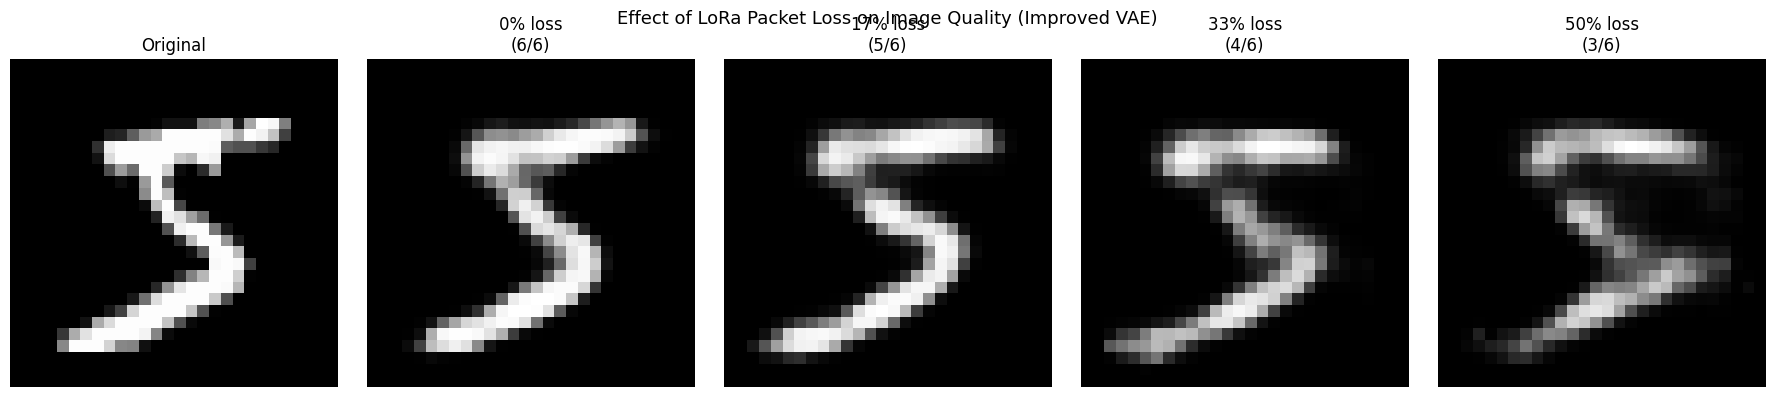

Saved: packet_loss_comparison.png
Reconstruction complete!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def reassemble_packets(received_packets, total_bytes=256):
    """
    Reassemble 6 packets — fill missing ones with zeros.
    total_bytes = 256 (64 floats x 4 bytes)
    """
    full_data = bytearray(total_bytes)
    for idx, packet in received_packets:
        if packet is not None:
            start = idx * 48
            end = start + len(packet)
            full_data[start:end] = packet
        else:
            print(f"  Packet {idx+1} missing - filling with zeros")
    return bytes(full_data)

def decode_from_packets(received_packets):
    reassembled = reassemble_packets(received_packets)
    recovered_array = np.frombuffer(reassembled, dtype=np.float32)
    recovered_tensor = torch.tensor(recovered_array).unsqueeze(0)
    with torch.no_grad():
        recon = model.decode(recovered_tensor).view(28, 28)
    return recon

# ── Decode all 4 test cases ──
model.eval()
with torch.no_grad():
    recon_0 = decode_from_packets(received_0)   # 0% loss
    recon_1 = decode_from_packets(received_1)   # 1 lost
    recon_2 = decode_from_packets(received_2)   # 2 lost
    recon_3 = decode_from_packets(received_3)   # 3 lost

# ── Show all 5 images ──
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(test_image.squeeze(), cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(recon_0.detach(), cmap='gray')
axes[1].set_title("0% loss\n(6/6)")
axes[1].axis('off')

axes[2].imshow(recon_1.detach(), cmap='gray')
axes[2].set_title("17% loss\n(5/6)")
axes[2].axis('off')

axes[3].imshow(recon_2.detach(), cmap='gray')
axes[3].set_title("33% loss\n(4/6)")
axes[3].axis('off')

axes[4].imshow(recon_3.detach(), cmap='gray')
axes[4].set_title("50% loss\n(3/6)")
axes[4].axis('off')

plt.suptitle("Effect of LoRa Packet Loss on Image Quality (Improved VAE)", fontsize=13)
plt.tight_layout()
plt.savefig('packet_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: packet_loss_comparison.png")
print("Reconstruction complete!")

In [ ]:
# Measure SSIM Score

In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np
import matplotlib.pyplot as plt

# ── Test on 20 different images ──
NUM_IMAGES = 20

results = []  # store per-image results

print("Testing SSIM on", NUM_IMAGES, "different MNIST digits...")
print("=" * 60)

model.eval()
with torch.no_grad():
    for idx in range(NUM_IMAGES):
        img, label = dataset[idx]
        img_input = img.unsqueeze(0)

        # Encode to latent vector
        mean, var = model.encode(img_input)
        compressed = model.reparameterise(mean, var)

        # Convert to bytes and split into 6 packets
        compressed_bytes = compressed.numpy().astype(np.float32).tobytes()
        packets = []
        for i in range(0, len(compressed_bytes), 48):
            packets.append(compressed_bytes[i:i+48])

        # ── Scenario 1: 0% loss (6/6) ──
        received_0 = [(i, p) for i, p in enumerate(packets)]

        # ── Scenario 2: 1 packet lost (5/6) ──
        received_1 = [(i, p if i != 2 else None) for i, p in enumerate(packets)]

        # ── Scenario 3: 2 packets lost (4/6) ──
        received_2 = [(i, p if i not in [2, 3] else None) for i, p in enumerate(packets)]

        # ── Scenario 4: 3 packets lost (3/6) ──
        received_3 = [(i, p if i not in [1, 2, 3] else None) for i, p in enumerate(packets)]

        # Reconstruct all 4 scenarios
        r0 = decode_from_packets(received_0)
        r1 = decode_from_packets(received_1)
        r2 = decode_from_packets(received_2)
        r3 = decode_from_packets(received_3)

        # Measure SSIM for each
        orig = img.squeeze()
        s0 = ssim(orig.numpy(), r0.detach().numpy(), data_range=1.0)
        s1 = ssim(orig.numpy(), r1.detach().numpy(), data_range=1.0)
        s2 = ssim(orig.numpy(), r2.detach().numpy(), data_range=1.0)
        s3 = ssim(orig.numpy(), r3.detach().numpy(), data_range=1.0)

        results.append({
            'idx': idx,
            'label': label,
            'ssim_0': s0,
            'ssim_1': s1,
            'ssim_2': s2,
            'ssim_3': s3
        })

        print(f"  Image {idx+1:2d} (digit {label}) | "
              f"0%: {s0:.4f} | 17%: {s1:.4f} | 33%: {s2:.4f} | 50%: {s3:.4f}")

# ── Calculate averages ──
avg_0 = np.mean([r['ssim_0'] for r in results])
avg_1 = np.mean([r['ssim_1'] for r in results])
avg_2 = np.mean([r['ssim_2'] for r in results])
avg_3 = np.mean([r['ssim_3'] for r in results])

std_0 = np.std([r['ssim_0'] for r in results])
std_1 = np.std([r['ssim_1'] for r in results])
std_2 = np.std([r['ssim_2'] for r in results])
std_3 = np.std([r['ssim_3'] for r in results])

print("\n" + "=" * 60)
print("      AVERAGE SSIM ACROSS 20 IMAGES")
print("=" * 60)
print(f"{'Scenario':<28} {'Avg SSIM':<12} {'Std Dev'}")
print("-" * 60)
print(f"{'0% loss  (6/6 packets)':<28} {avg_0:.4f}       ±{std_0:.4f}")
print(f"{'17% loss (5/6 packets)':<28} {avg_1:.4f}       ±{std_1:.4f}")
print(f"{'33% loss (4/6 packets)':<28} {avg_2:.4f}       ±{std_2:.4f}")
print(f"{'50% loss (3/6 packets)':<28} {avg_3:.4f}       ±{std_3:.4f}")
print("=" * 60)

# ── Bar chart of averages ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['0%\n(6/6)', '17%\n(5/6)', '33%\n(4/6)', '50%\n(3/6)']
avgs   = [avg_0, avg_1, avg_2, avg_3]
stds   = [std_0, std_1, std_2, std_3]
colors = ['#2E75B6', '#70AD47', '#FFC000', '#FF6B6B']

bars = axes[0].bar(labels, avgs, color=colors, width=0.5, yerr=stds,
                   capsize=5, error_kw={'linewidth': 1.5})
axes[0].set_ylim(0, 1.0)
axes[0].set_title(f'Average SSIM Across {NUM_IMAGES} Images', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Packet Loss Rate')
axes[0].set_ylabel('Average SSIM Score')
axes[0].axhline(y=0.8, color='green',  linestyle='--', label='Good (0.80)', linewidth=1)
axes[0].axhline(y=0.6, color='orange', linestyle='--', label='Acceptable (0.60)', linewidth=1)
axes[0].legend(fontsize=9)
for i, (v, s) in enumerate(zip(avgs, stds)):
    axes[0].text(i, v + s + 0.03, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# ── Per-image SSIM line plot ──
x = range(1, NUM_IMAGES + 1)
axes[1].plot(x, [r['ssim_0'] for r in results], 'o-', color='#2E75B6', label='0% loss',  linewidth=1.5, markersize=4)
axes[1].plot(x, [r['ssim_1'] for r in results], 's-', color='#70AD47', label='17% loss', linewidth=1.5, markersize=4)
axes[1].plot(x, [r['ssim_2'] for r in results], '^-', color='#FFC000', label='33% loss', linewidth=1.5, markersize=4)
axes[1].plot(x, [r['ssim_3'] for r in results], 'D-', color='#FF6B6B', label='50% loss', linewidth=1.5, markersize=4)
axes[1].set_title(f'SSIM Per Image ({NUM_IMAGES} digits)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Image Index')
axes[1].set_ylabel('SSIM Score')
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(x)

plt.suptitle('Improved VAE — SSIM Validation Across Multiple Images',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ssim_validation_20images.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: ssim_validation_20images.png")

from google.colab import files
files.download('ssim_validation_20images.png')

      IMAGE QUALITY RESULTS
SSIM (0% loss  — 6/6 packets):  0.9102
SSIM (17% loss — 5/6 packets):  0.7868
SSIM (33% loss — 4/6 packets):  0.6671
SSIM (50% loss — 3/6 packets):  0.4954
Score guide:
  1.00 = Perfect
  0.80+ = Very good
  0.60+ = Acceptable
  Below 0.60 = Poor

Dissertation Results Table:
---------------------------------------------
Scenario                  Packets RX   SSIM
---------------------------------------------
No loss                   6/6          0.9102
1 packet lost (17%)       5/6          0.7868
2 packets lost (33%)      4/6          0.6671
3 packets lost (50%)      3/6          0.4954
---------------------------------------------
Quality measurement done!


In [ ]:
# Graph for Dissertation

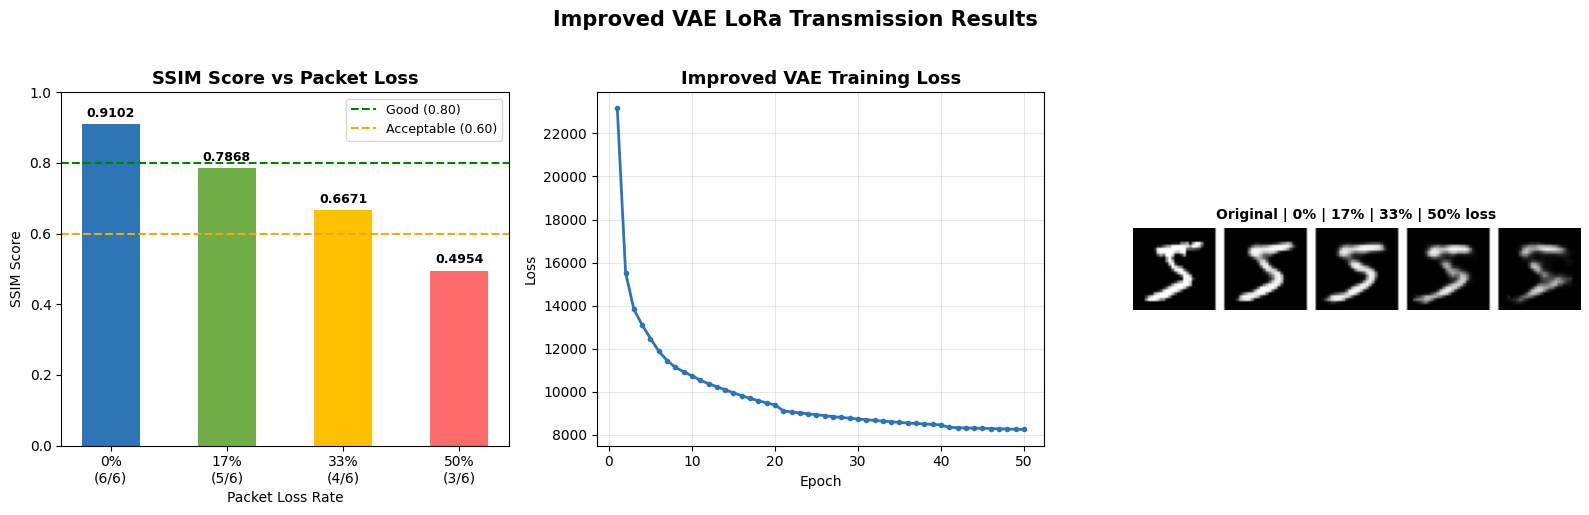

Saved: dissertation_results_improved.png

           FINAL RESULTS SUMMARY
Metric                              Value
-------------------------------------------------------
Original image size                 784 numbers
Compressed size                     64 numbers
Compression ratio                   12x smaller
Payload size                        256 bytes
Packets needed                      6 packets
SSIM (0% loss)                      0.9102
SSIM (17% loss — 1 pkt lost)        0.7868
SSIM (33% loss — 2 pkts lost)       0.6671
SSIM (50% loss — 3 pkts lost)       0.4954


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Graph 1: SSIM Bar Chart ──
labels  = ['0%\n(6/6)', '17%\n(5/6)', '33%\n(4/6)', '50%\n(3/6)']
scores  = [ssim_0, ssim_1, ssim_2, ssim_3]
colors  = ['#2E75B6', '#70AD47', '#FFC000', '#FF6B6B']

axes[0].bar(labels, scores, color=colors, width=0.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('SSIM Score vs Packet Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Packet Loss Rate')
axes[0].set_ylabel('SSIM Score')
axes[0].axhline(y=0.8, color='green',  linestyle='--', label='Good (0.80)')
axes[0].axhline(y=0.6, color='orange', linestyle='--', label='Acceptable (0.60)')
axes[0].legend(fontsize=9)
for i, v in enumerate(scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# ── Graph 2: Training Loss Curve ──
axes[1].plot(range(1, len(losses)+1), losses, color='#2E75B6', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Improved VAE Training Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

# ── Graph 3: Image comparison strip ──
divider = np.ones((28, 3))
comparison = np.hstack([
    test_image.squeeze().numpy(), divider,
    recon_0.detach().numpy(),     divider,
    recon_1.detach().numpy(),     divider,
    recon_2.detach().numpy(),     divider,
    recon_3.detach().numpy()
])
axes[2].imshow(comparison, cmap='gray')
axes[2].set_title('Original | 0% | 17% | 33% | 50% loss', fontsize=10, fontweight='bold')
axes[2].axis('off')

plt.suptitle('Improved VAE LoRa Transmission Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dissertation_results_improved.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: dissertation_results_improved.png")

# ── Summary Table ──
print("\n" + "=" * 55)
print("           FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"{'Metric':<35} {'Value'}")
print("-" * 55)
print(f"{'Original image size':<35} 784 numbers")
print(f"{'Compressed size':<35} 64 numbers")
print(f"{'Compression ratio':<35} 12x smaller")
print(f"{'Payload size':<35} 256 bytes")
print(f"{'Packets needed':<35} 6 packets")
print(f"{'SSIM (0% loss)':<35} {ssim_0:.4f}")
print(f"{'SSIM (17% loss — 1 pkt lost)':<35} {ssim_1:.4f}")
print(f"{'SSIM (33% loss — 2 pkts lost)':<35} {ssim_2:.4f}")
print(f"{'SSIM (50% loss — 3 pkts lost)':<35} {ssim_3:.4f}")
print("=" * 55)


from google.colab import files
files.download('dissertation_results_improved.png')
files.download('packet_loss_comparison.png')